4076


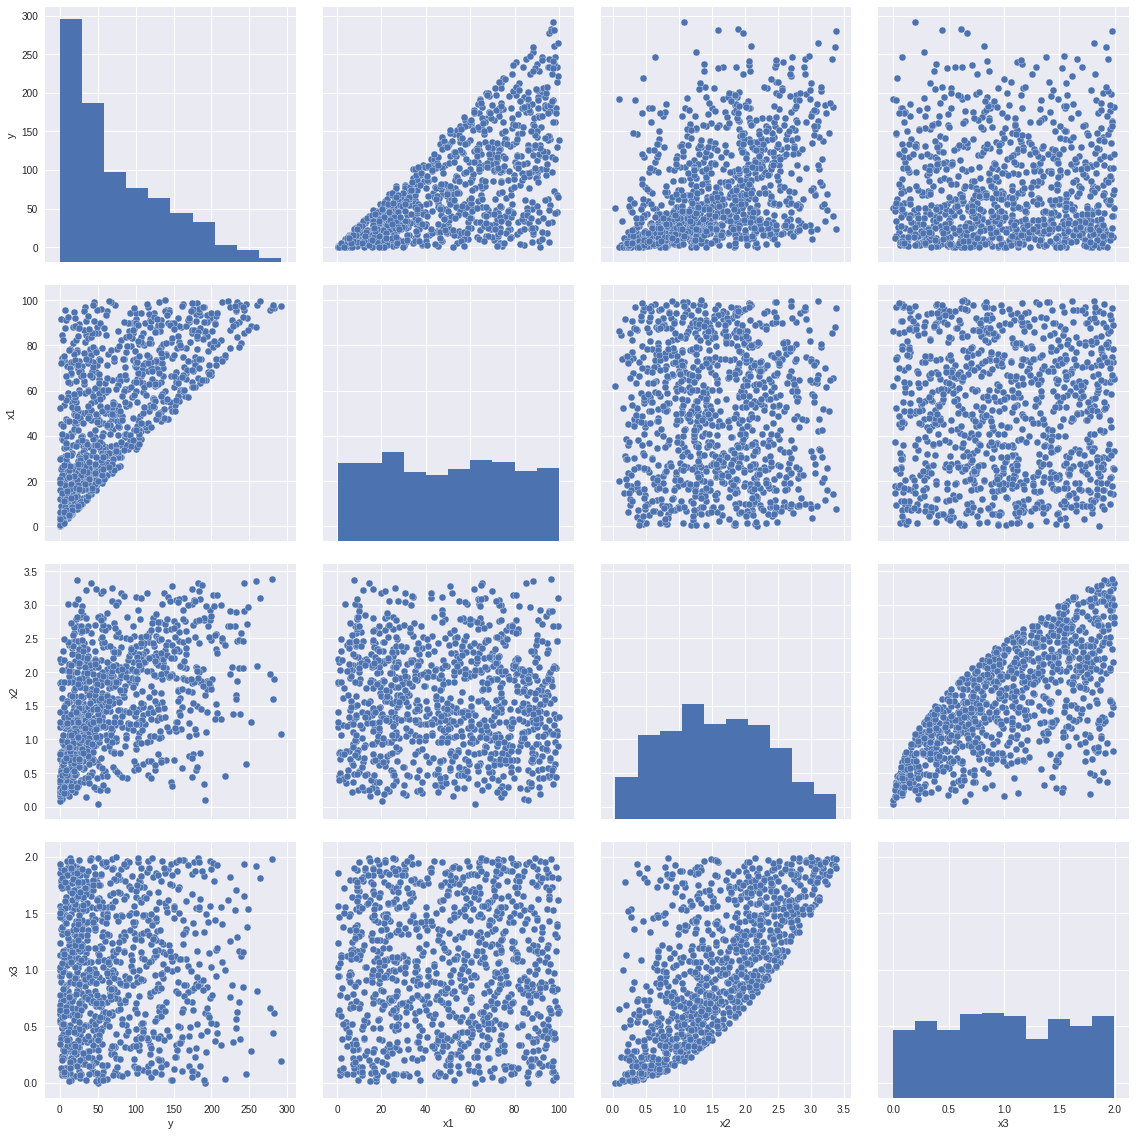

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

df_raw = pd.read_csv('ML_Data_Insight_121016.csv', header=1) 
cols = ['y','x1', 'x2', 'x3'] 
df_raw.head()

df = df_raw
#df = df_raw.ix[df_raw['y'] < 100]

df.drop_duplicates()

print(np.size(df))

sns.pairplot(df[cols], size=4) 
plt.show()

color_t= '#3333ff'
color_t_fit= '#0000cc'
color_v = '#00ff00'
color_v_fit = '#0099c4'



#df[df['coverage'] > 50]
#df = df_raw


In [23]:

#sns.set(style='whitegrid', context='notebook')

#sns.pairplot(df[cols], size=4)
#plt.show()


In [24]:
print ( df.cov() )
print ( df.corr() )


              y           x1         x2        x3
y   4133.446622  1232.772400  21.546143  0.440736
x1  1232.772400   826.455605  -0.446825  0.139798
x2    21.546143    -0.446825   0.616575  0.305066
x3     0.440736     0.139798   0.305066  0.327083
           y        x1        x2        x3
y   1.000000  0.666986  0.426796  0.011987
x1  0.666986  1.000000 -0.019794  0.008503
x2  0.426796 -0.019794  1.000000  0.679316
x3  0.011987  0.008503  0.679316  1.000000


/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


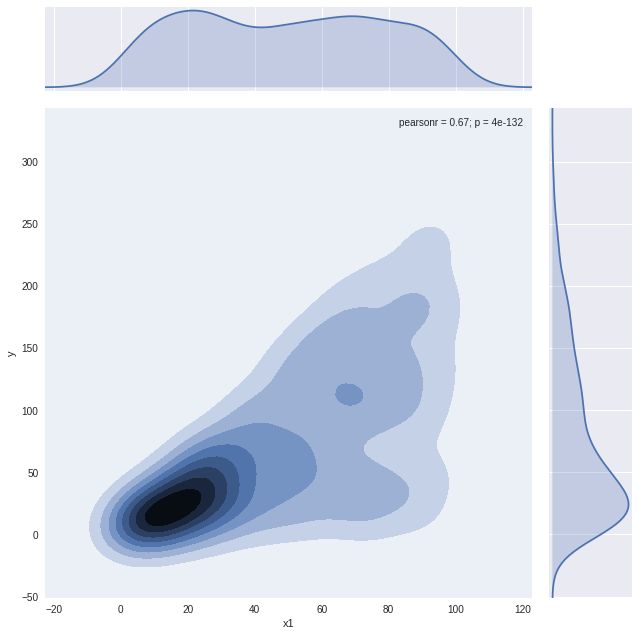

In [25]:
sns.jointplot(x="x1", y="y", data=df, kind="kde", size=9)
plt.show()



/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


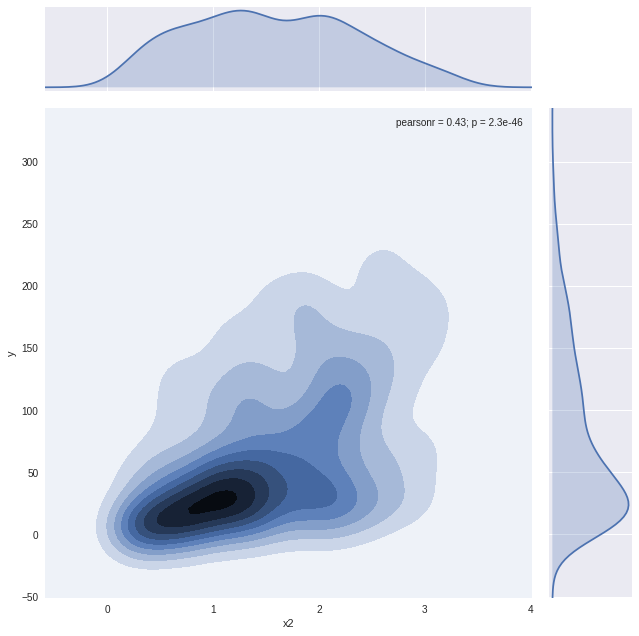

In [26]:
sns.jointplot(x="x2", y="y", data=df, kind="kde", size=9)
plt.show()

/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


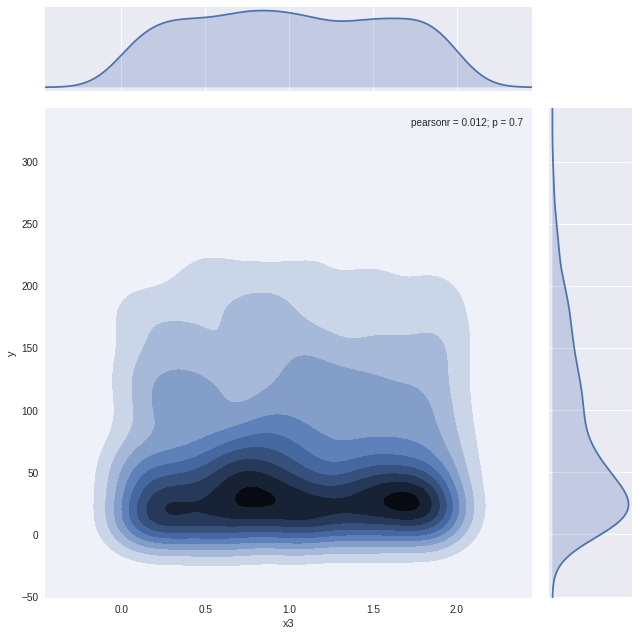

In [27]:
sns.jointplot(x="x3", y="y", data=df, kind="kde", size=9)
plt.show()

/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


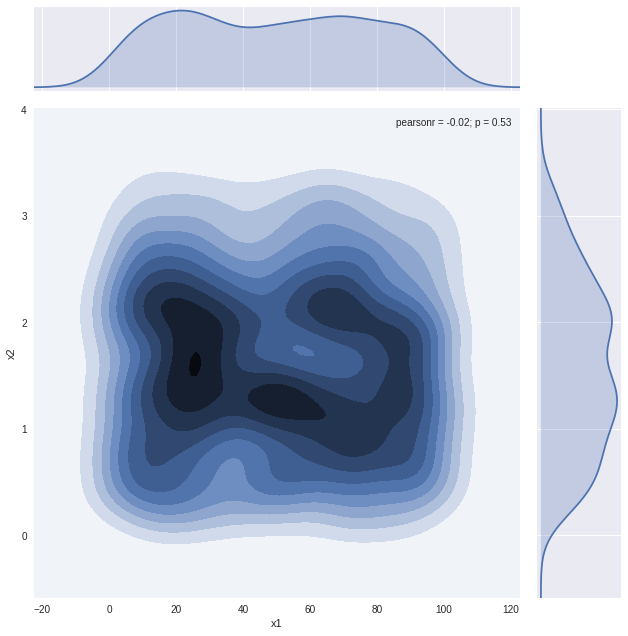

In [28]:
sns.jointplot(x="x1", y="x2", data=df, kind="kde", size=9)
plt.show()


/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


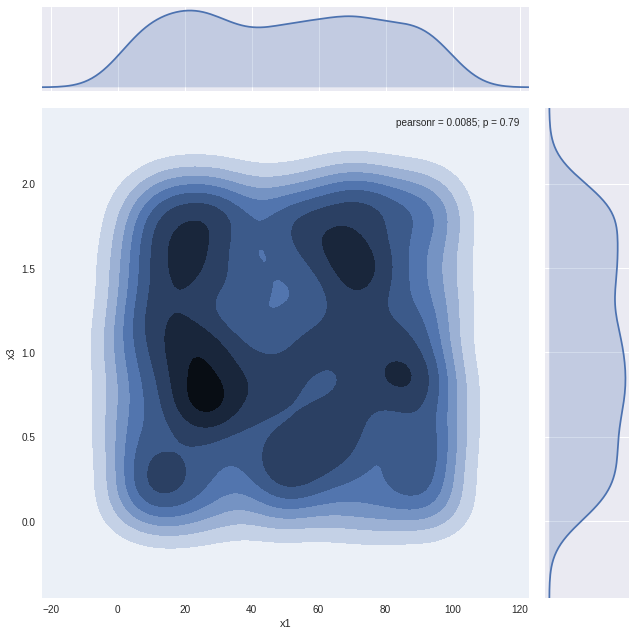

In [29]:
sns.jointplot(x="x1", y="x3", data=df, kind="kde", size=9)
plt.show()

/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


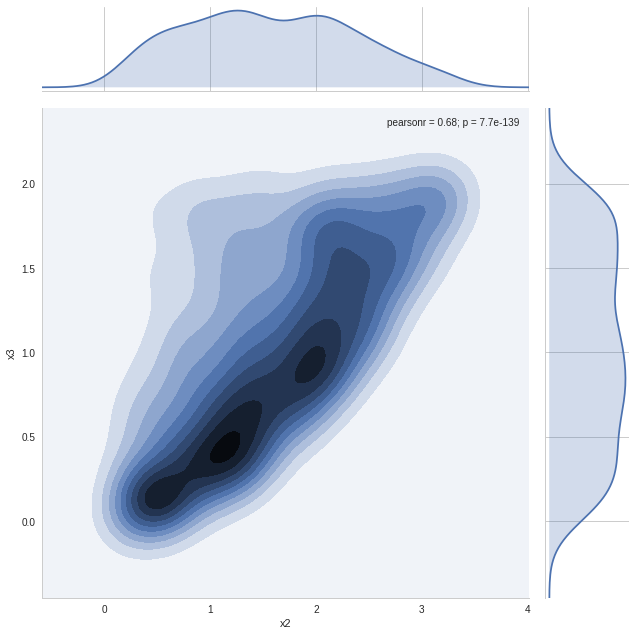

In [184]:
sns.jointplot(x="x2", y="x3", data=df, kind="kde", size=9)
plt.show()

In [292]:
from mpl_toolkits.mplot3d import Axes3D

In [30]:
#fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# Axes3D.contour(X, Y, Z, *args, **kwargs)¶

In [2]:
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import scale
from collections import Counter

In [5]:
# Prøver lineær regresjon selv om vi ser at sammenhengen er noe mere kompliser for enkelte av variablene. 
# Vi har kun 3 features og ett relativt lite datasett. Det vil si at det kun er 8 mulige
# kombinasjoner av input features: x1, x2, x3, x1x2,x1x3, x2x3 og x1x2x3. (I prinsippet 9
# hvis vi antar att y er uavhengig av all input variable, men vi ser av datasettet at dette ikke er  tilfelle )
# Vi bare prøver oss frem med all mulig kombinasjoner og ser hva som gir best resultat
# Antar att datsettet er u-ordnet. De 800 første rekkene brukes til generering av modell, og de resterenede
# til validering

lm = LinearRegression(normalize=True)

y_train=df.ix[0:800, (0)]
x1x2x3_train=df.ix[0:800, (1,2,3)]
x1x2_train=df.ix[0:800, (1,2)]
x1x3_train=df.ix[0:800, (1,3)]
x2x3_train=df.ix[0:800, (2,3)]
x1_train=df.ix[0:800, (1)]
x2_train=df.ix[0:800, (2)]
x3_train=df.ix[0:800, (3)]

y_val=df.ix[801:, (0)]
x1x2x3_val=df.ix[801:, (1,2,3)]
x1x2_val=df.ix[801:, (1,2)]
x1x3_val=df.ix[801:, (1,3)]
x2x3_val=df.ix[801:, (2,3)]
x1_val=df.ix[801:, (1)]
x2_val=df.ix[801:, (2)]
x3_val=df.ix[801:, (3)]

In [6]:
def fit_linear(X_t, y_t, X_v, y_v, name, height=8):
    g=(np.sqrt(5) +1)/2
    lm.fit(X_t, y_t)
    print ("Model score [0,1] using", name)
    print ("LMS Score for training data:\t", lm.score(X_t, y_t ))
    print ("LMS Score for validation data:\t", lm.score(X_v, y_v )) 
    
    y_pt=lm.predict(X_t)
    y_pt_diff =  y_pt - y_t
    
    y_pv=lm.predict(X_v)
    y_pv_diff =  y_pv - y_v
    
    hmin = min( y_pt.min(),y_pv.min())
    hmax = max( y_pt.max(),y_pv.max())
    plt.figure(1, figsize=(g*height, height))
    plt.scatter(y_pt, y_pt - y_t, c=color_t, s=40, alpha=0.5)
    plt.scatter(y_pv, y_pv - y_v, c=color_v, s=40, alpha=0.5)
    plt.hlines(y=0, xmin=hmin, xmax=hmax)
    plt.title('Residual Plot using training data (blue) and test data (green)')
    plt.show()
        

Model score [0,1] using x1, x2, x3
LMS Score for training data:	 0.805415155915
LMS Score for validation data:	 0.767317865862


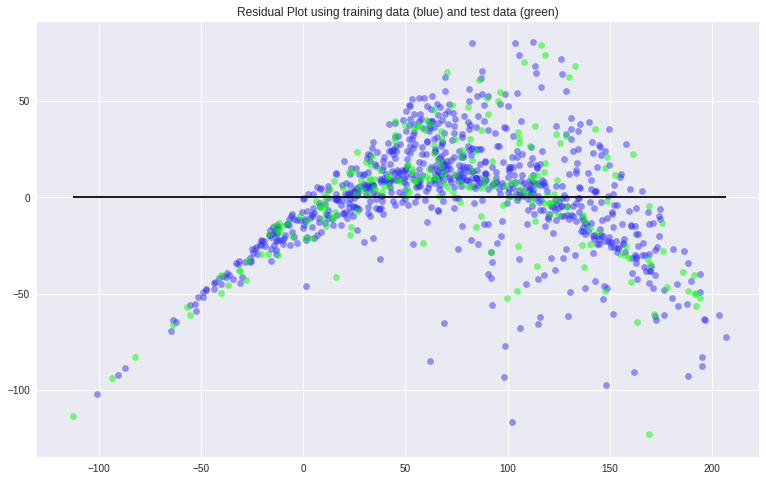

In [7]:
fit_linear(x1x2x3_train, y_train, x1x2x3_val, y_val, 'x1, x2, x3' )

In [13]:
# Ser av rest plottet at modellen ikke er spesielt god. For en god modell så burde residuen 
# verdien værr normal fordelt med mean = 0. AV formen på residuene så er det nærliggende
# å forsøke en polynom tilpasning, et 2-grads polynom ser ut til å skulle holde.
#Vi ser av det forehåned at vi får best resultat når vi bruker alle featurene x1, x2, x3, så vi bruker denne modellen

Model score [0,1] using x1, x2
LMS Score for training data:	 0.637198017109
LMS Score for validation data:	 0.641323441714


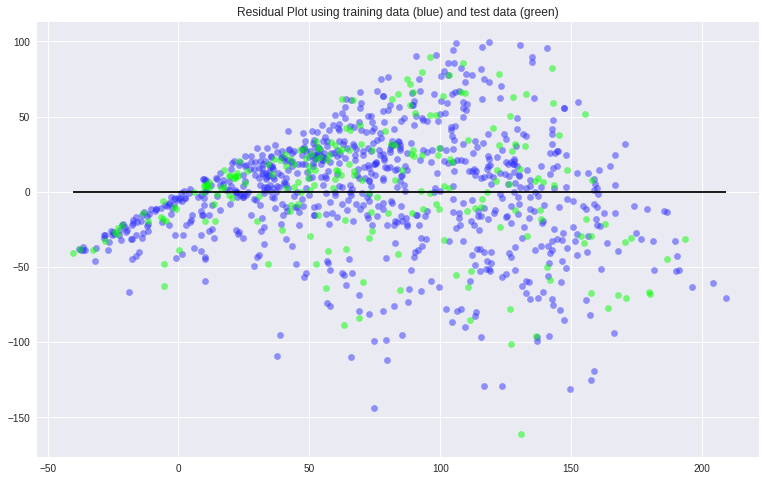

In [14]:
fit_linear(x1x2_train, y_train, x1x2_val, y_val, 'x1, x2' )

Model score [0,1] using x1, x3
LMS Score for training data:	 0.454026094636
LMS Score for validation data:	 0.410980812189


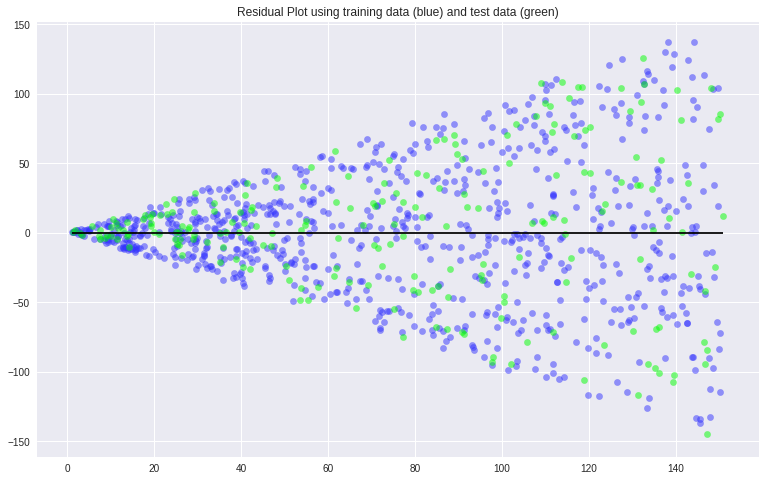

In [15]:
fit_linear(x1x3_train, y_train, x1x3_val, y_val, 'x1, x3' )

Model score [0,1] using x1, x3
LMS Score for training data:	 0.309558986877
LMS Score for validation data:	 0.380209049625


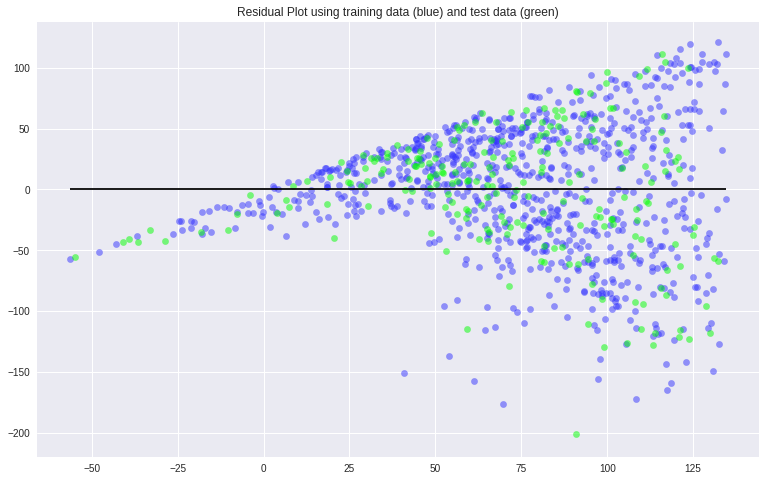

In [16]:
fit_linear(x2x3_train, y_train, x2x3_val, y_val, 'x1, x3' )

Model score [0,1] using x1
LMS Score for training data:	 0.454024668386
LMS Score for validation data:	 0.411061772764


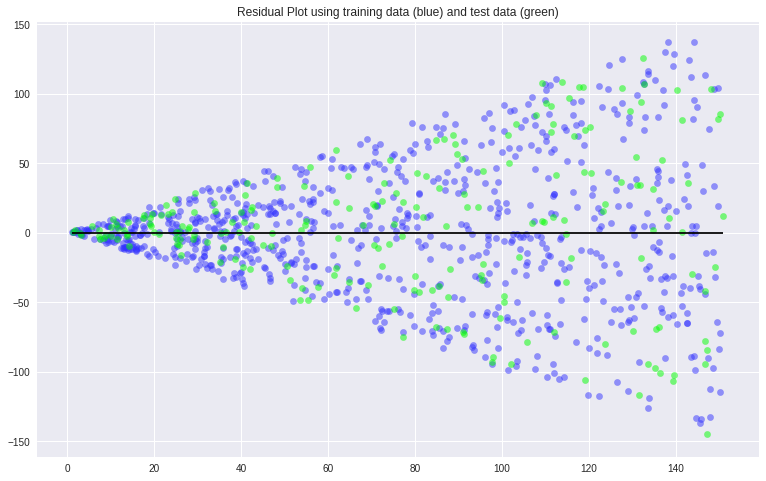

In [17]:
fit_linear(x1_train.values.reshape(-1,1), y_train.values.reshape(-1,1), x1_val.values.reshape(-1,1), y_val.values.reshape(-1,1), 'x1' )


Model score [0,1] using x2
LMS Score for training data:	 0.170057646016
LMS Score for validation data:	 0.222508055507


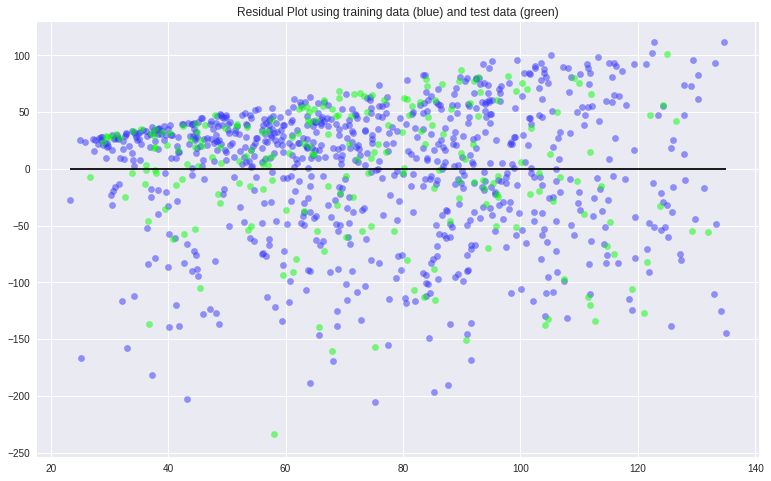

In [18]:
fit_linear(x2_train.values.reshape(-1,1), y_train.values.reshape(-1,1), x2_val.values.reshape(-1,1), y_val.values.reshape(-1,1), 'x2' )


Model score [0,1] using x3
LMS Score for training data:	 0.000192378969286
LMS Score for validation data:	 -0.00138585960231


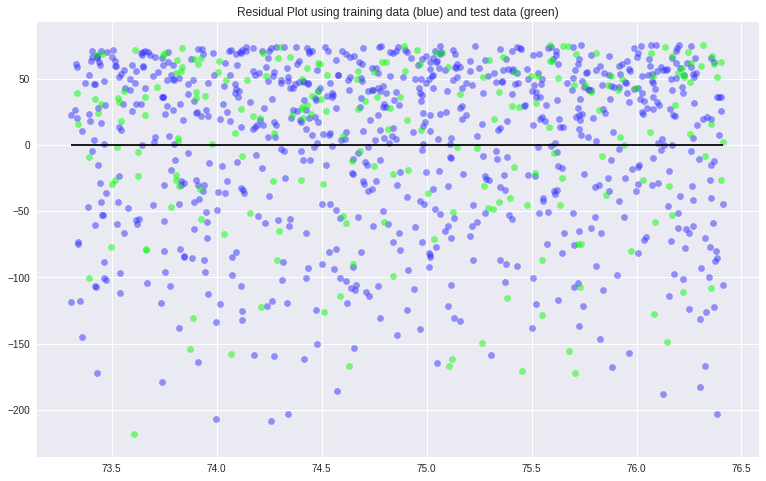

In [35]:
fit_linear(x3_train.values.reshape(-1,1), y_train.values.reshape(-1,1), x3_val.values.reshape(-1,1), y_val.values.reshape(-1,1), 'x3' )


In [28]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model
import matplotlib.pyplot as plt
from decimal import *
from scipy.stats import norm
import matplotlib.mlab as mlab

def fit_poly(deg, nbins=100, height=8):
    g=(np.sqrt(5) +1)/2
    poly = PolynomialFeatures(degree=deg)
    X_train = poly.fit_transform(x1x2x3_train, (1,2,3))
    
    X_val   = poly.fit_transform(x1x2x3_val, (1,2,3))    
    print("Params= ",  poly.get_params())
   # poly.get_params()
    
    clf = linear_model.LinearRegression()
 #   lf = linear_model.LinearRegression()
    clf.fit(X_train, y_train )
    res_train =  clf.predict(X_train) - y_train
    res_val = clf.predict(X_val) - y_val
   # plt.subplot(111)
    plt.figure(1, figsize=(g*height, height))
    plt.scatter(clf.predict(X_train), res_train, c=color_t, s=40, alpha=0.5)
    plt.scatter(clf.predict(X_val), res_val, c=color_v, s=40, alpha=0.5)
    #plt.hlines(y=0, xmin=-130, xmax=210)
   
    plt.title('Residual plot som viser trenings data (blå) og validerings data (grønn)')
    print ("Model score [0,1] med x1,x2,x3 som input og en lineariserende polynom transformasjon av grad", deg)
    print ("LMS Score for treningsdata:\t%0.4f" % clf.score(X_train, y_train ))
    print ("LMS Score for validerings data:\t%0.4f" % clf.score(X_val, y_val ))
   # plt.figure(2, figsize=(16,8))
    plt.figure(2, figsize=(g*height, height))
    n_t, bins_t, patches_t = plt.hist(res_train, bins=nbins, normed=True)
    n_v, bins_v, patches_v = plt.hist(res_val, bins=nbins,normed=True )
    
    #(mu, sigma) = norm.fit(h1)
   # mu_t,sigma_t = norm.fit(res_train, mu=0, sigma=14, range=(-25,25))
    mu_t,sigma_t = norm.fit(res_train, range=(-25, 25))
    mu_v,sigma_v = norm.fit(res_val, range=(-25, 25 ) )
    
    print("mu_t=\t", mu_t)
    print("Sigma_t=\t", sigma_t)
    print("mu_v=\t", mu_v)
    print("Sigma_v=\t", sigma_v)
    
    y_t = mlab.normpdf( bins_t, mu_t, sigma_t/2 )
    y_v = mlab.normpdf( bins_t, mu_t, sigma_v/2 )
    
   # print("the sum of the bins is", np.sum(np.abs(bins_t)))
   # print(y)
    
    ##y=  1000*y
    
   # plt.xlim(-25,25)
    l = plt.plot(bins_t, y_t, c=color_t_fit, linewidth=2, linestyle='--')
    l = plt.plot(bins_t, y_v, c=color_v_fit, linewidth=2,linestyle='--')
    
    print("Training data residuals std:\t%0.4f" % np.std(res_train))
    print("Training data mean:\t\t%0.4f" % np.mean(res_train))
    print("Validation data residuals std:\t%0.4f" % np.std(res_val))
    print("Validation data mean:\t\t%0.4f" % np.mean(res_val))    
  #  plt.figure(3) 
    plt.show()

Params=  {'degree': 2, 'include_bias': True, 'interaction_only': False}
Model score [0,1] med x1,x2,x3 som input og en lineariserende polynom transformasjon av grad 2
LMS Score for treningsdata:	0.9500
LMS Score for validerings data:	0.9454
mu_t=	 2.11069336513e-13
Sigma_t=	 14.3067768068
mu_v=	 2.26329458962
Sigma_v=	 15.0656080725
Training data residuals std:	14.3068
Training data mean:		0.0000
Validation data residuals std:	15.0656
Validation data mean:		2.2633


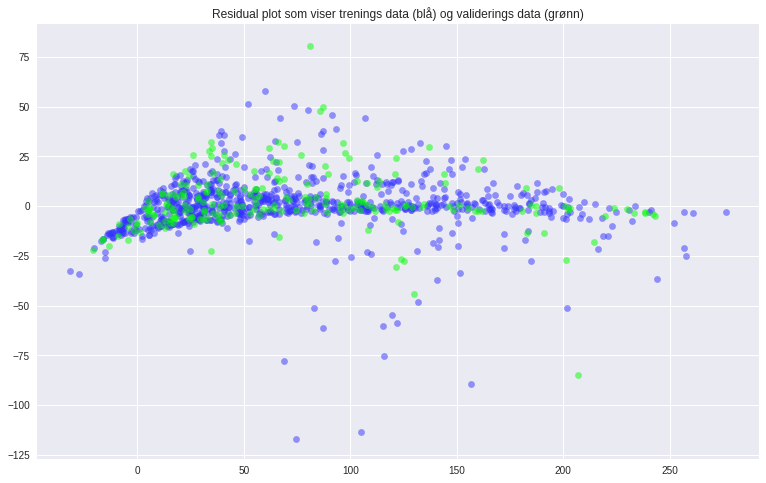

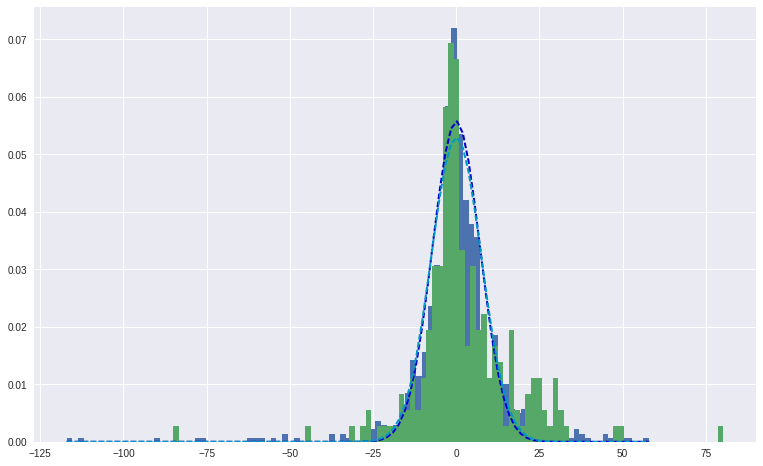

In [29]:
fit_poly(2)

Model score [0,1] med x1,x2,x3 som input og en lineariserende polynom transformasjon av grad 3
LMS Score for treningsdata:	0.9746
LMS Score for validerings data:	0.9767
mu_t=	 4.23194285829e-13
Sigma_t=	 10.1904156393
mu_v=	 0.629805909735
Sigma_v=	 9.92763877511
Training data residuals std:	10.1904
Training data mean:		0.0000
Validation data residuals std:	9.9276
Validation data mean:		0.6298


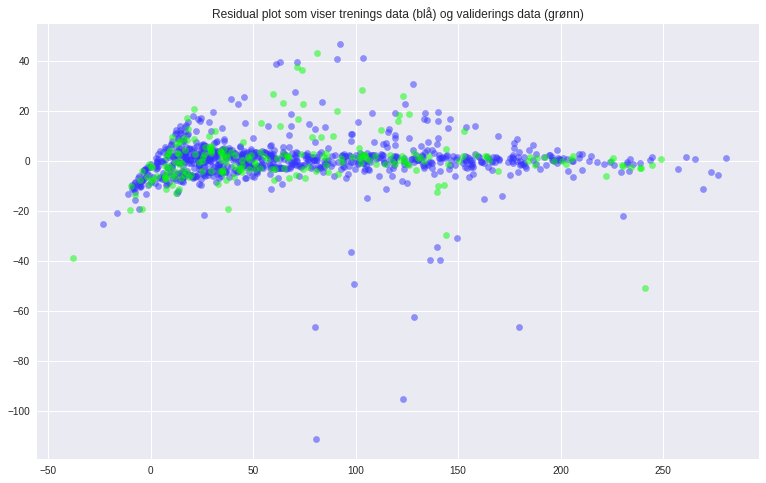

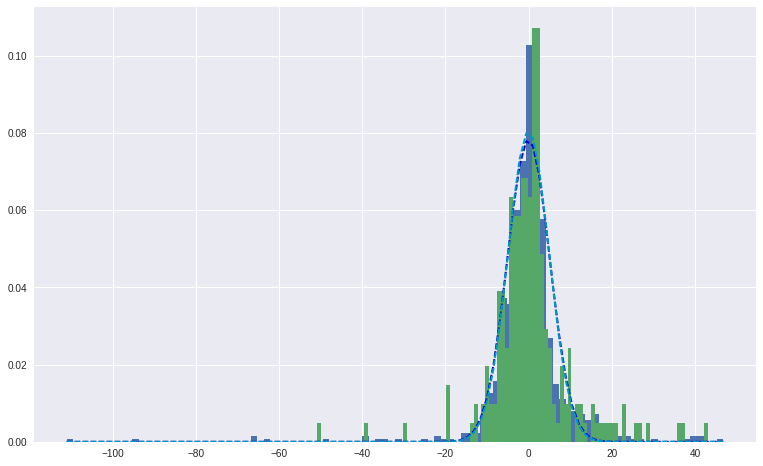

In [23]:
fit_poly(3)

Model score [0,1] med x1,x2,x3 som input og en lineariserende polynom transformasjon av grad 4
LMS Score for treningsdata:	0.9841
LMS Score for validerings data:	0.9862
mu_t=	 -9.54478958348e-10
Sigma_t=	 8.07143987321
mu_v=	 0.679210587765
Sigma_v=	 7.62607010415
Training data residuals std:	8.0714
Training data mean:		-0.0000
Validation data residuals std:	7.6261
Validation data mean:		0.6792


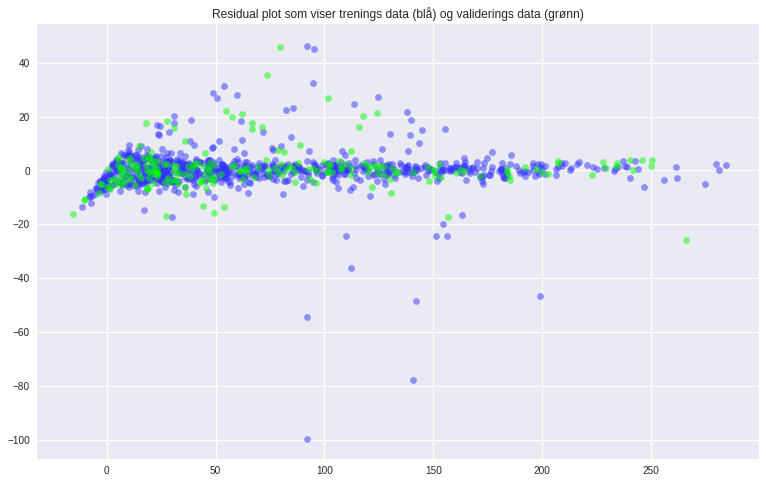

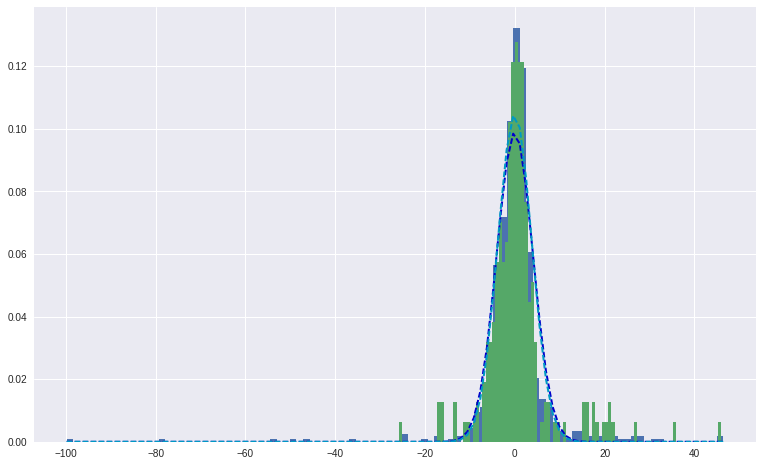

In [24]:
fit_poly(4)


Params=  {'degree': 5, 'include_bias': True, 'interaction_only': False}
Model score [0,1] med x1,x2,x3 som input og en lineariserende polynom transformasjon av grad 5
LMS Score for treningsdata:	0.9896
LMS Score for validerings data:	0.9917
mu_t=	 7.18279756661e-12
Sigma_t=	 6.5371981937
mu_v=	 0.0516191629898
Sigma_v=	 5.92364263705
Training data residuals std:	6.5372
Training data mean:		0.0000
Validation data residuals std:	5.9236
Validation data mean:		0.0516


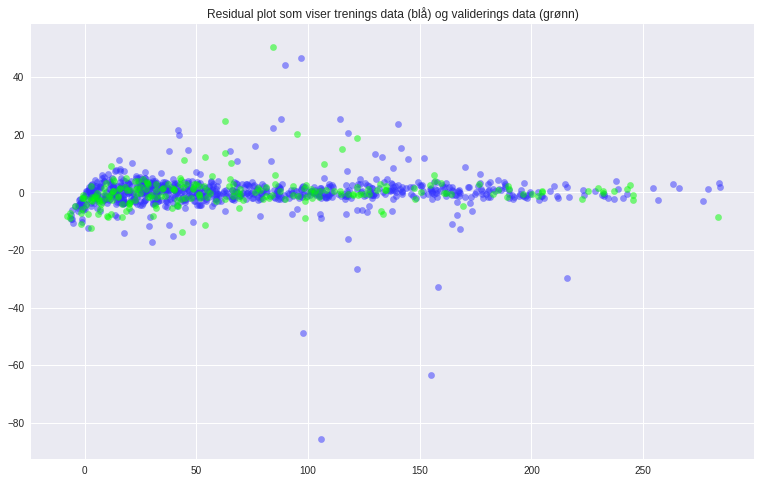

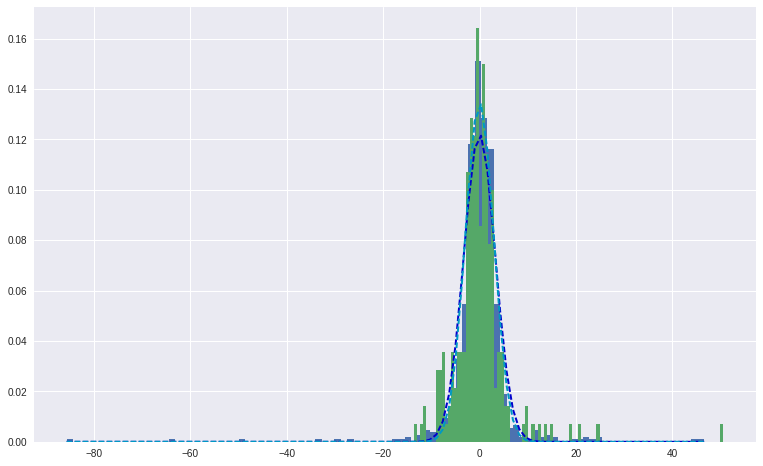

In [34]:
fit_poly(5)

Params=  {'degree': 6, 'include_bias': True, 'interaction_only': False}
Model score [0,1] med x1,x2,x3 som input og en lineariserende polynom transformasjon av grad 6
LMS Score for treningsdata:	0.9930
LMS Score for validerings data:	0.9926
mu_t=	 5.60929136403e-12
Sigma_t=	 5.34321071341
mu_v=	 0.39904939149
Sigma_v=	 5.59476083237
Training data residuals std:	5.3432
Training data mean:		0.0000
Validation data residuals std:	5.5948
Validation data mean:		0.3990


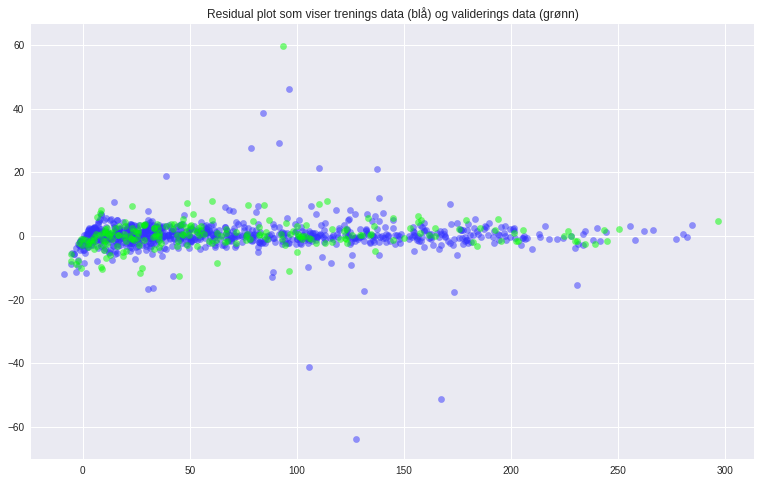

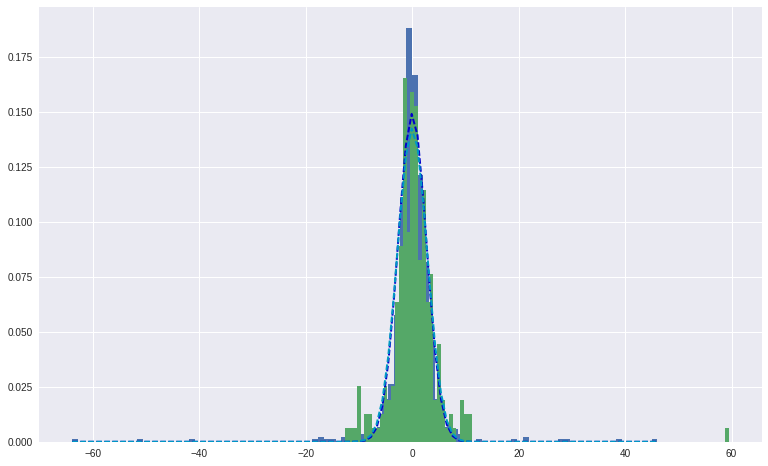

In [35]:
fit_poly(6) 
#dette ser rimelig greit ut, hvis man går høyre opp i polynomgrad så risikerer mant 2 ting. 
# 1) Løsningen blir numerisk ustabil
# 2) anall frihetsgrader øker så my at løsningen fort kan ta seg en tur innom outlierne
# må huske på at med n=6 så får vi ikke bare 3x8 = 18 frihetsgrader, men også alle kryss porduktene

Model score [0,1] med x1,x2,x3 som input og en lineariserende polynom transformasjon av grad 7
LMS Score for treningsdata:	0.9570
LMS Score for validerings data:	0.8767
mu_t=	 -1.03887025213e-11
Sigma_t=	 13.2678304974
mu_v=	 1.36511741774
Sigma_v=	 22.8493826393
Training data residuals std:	13.2678
Training data mean:		-0.0000
Validation data residuals std:	22.8494
Validation data mean:		1.3651


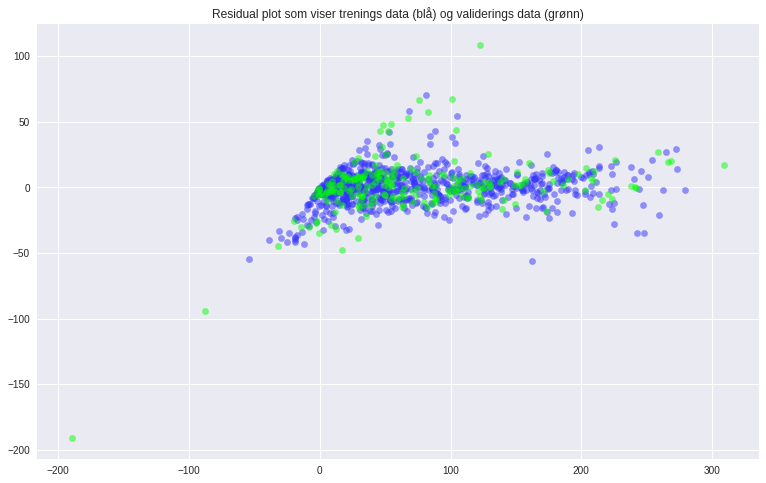

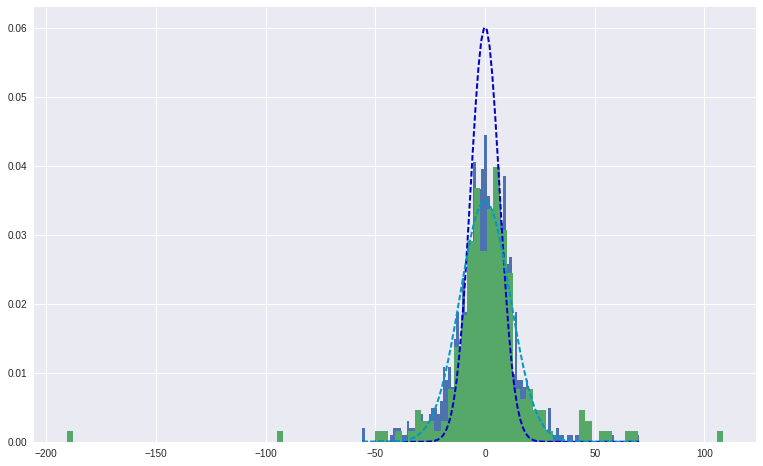

In [10]:
fit_poly(7)
# Går vi høyer oppe en n=6 så får vi problemer med overfitting

# Results
## The model
The best model acheived with linearizing polynomials is

$$y_k=\prod_{n=1}^{3}\bigg{(}\sum_{m=0}^6 a_{nm}x_{k}^{m}\bigg{)}$$
Where Yk is the measurement at index k

SyntaxError: invalid syntax (<ipython-input-33-48678ae8fc4a>, line 1)